In [1]:
import os, sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

### Please check _common.py for common paths, loaded packages and functions
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## ASOS stations nearby

In [2]:
# Read seismic station list
sta_info = pd.read_csv(os.path.join(data_dir, 'TA/TA_list.csv'))

# Read ASOS station metadata
csv_files = [os.path.join(data_dir, 'ASOS/LA_meta.csv')]
asos_info = read_asos_metadata(csv_files)

# Find nearest ASOS station
geod = Geod(ellps="WGS84")
matches = []

for i, row in asos_info.iterrows():
    lat1, lon1 = row['lat'], row['lon']
    
    # Compute distances to all sta_info points
    _, _, dist = geod.inv(
        np.full(len(sta_info), lon1),
        np.full(len(sta_info), lat1),
        sta_info['lon'].values,
        sta_info['lat'].values
    )
    
    min_dist = dist.min() / 1000.0  # convert to km
    if min_dist <= 20:
        j = dist.argmin()
        nearest = sta_info.iloc[j]
        matches.append({'asos_sta': row['stid'], 'asos_lat': lat1, 'asos_lon': lon1,
                        'sta_index': nearest.stnm, 'sta_lat': nearest['lat'], 'sta_lon': nearest['lon'],
                        'distance_km': min_dist})

match_info = pd.DataFrame(matches)
match_info = match_info.sort_values('distance_km').drop_duplicates(subset='sta_index', keep='first')
match_info = match_info.reset_index(drop=True)
match_info

,asos_sta,asos_lat,asos_lon,sta_index,sta_lat,sta_lon,distance_km
0,AQV,31.35691,-93.17605,341A,31.333401,-93.168098,2.714186
1,ESF,31.39634,-92.28273,342A,31.374701,-92.324898,4.673752
2,ARA,30.02918,-91.88453,543A,30.085600,-91.855698,6.844480
3,LCH,30.12550,-93.22770,541A,30.059601,-93.187500,8.269354
4,MLU,32.51086,-92.03769,142A,32.548801,-91.945702,9.611722
5,APS,30.08600,-90.58420,545A,30.044100,-90.489403,10.253053
6,HUM,29.56650,-90.66042,645A,29.457300,-90.596603,13.593935
7,ASD,30.34330,-89.82220,546A,30.233000,-89.719101,15.744691
8,DRI,30.83000,-93.34000,441A,30.749800,-93.189796,16.903867
9,BAD,32.50193,-93.66263,140A,32.640800,-93.573997,17.505356


## Download infrasound data

In [ ]:
# List of stations
stnm_list1 = match_info['sta_index'].values
stnm_list2 = ['241A', '244A', '442A', '443A', '445A', '447A', '544A', '646A']
stnm_list = np.concatenate([stnm_list1, stnm_list2])

# Time interval of infrasound data
ts, te = UTCDateTime(2012, 8, 24, 20), UTCDateTime(2012, 9, 1, 4)

# Download infrasound data
for stnm in stnm_list:
    if os.path.exists(os.path.join(data_dir, 'TA/mseeds', f'BDF_{stnm}.mseed')):
        print(f'Found existing file for station {stnm}')
        continue
    trace, sta_loc = download_trace(['TA', stnm], [ts, te], 'BDF', pre_filt=[5e-4, 1e-3, 18, 20], 
                                    extra_portion=0, client=Client('IRIS'))
    trace.stats.latitude = sta_loc[1]
    trace.stats.longitude = sta_loc[0]
    st = trace.split()
    # st.write(os.path.join(data_dir, 'TA/mseeds', f'BDF_{stnm}.mseed'), format='MSEED')

## Compute pressure PSD & amplitude

In [3]:
### PSD parameters ###

# Welch parameters
dt = 1/40                       # Sampling interval (s)
window = 15 * 60                # Window length (s)
nfreqs = 200                    # Number of frequency samples
nperseg = int(200 / dt)         # Sample points per each Welch segment
noverlap = int(nperseg * 0.5)   # Overlap points between segments

# Smoothing parameters
smooth_mode = 'nearest'
smooth_poly = 1
smooth_npts = 20

# Filter parameters
fmin, fmax = 0.005, 15              # For PSD calculation
frms_min, frms_max = 0.005, 10      # For amplitude calculation

In [ ]:
### Calculate pressure PSD ###

# Directory of infrasound data
turb_dir = os.path.join(data_dir, 'TA/mseeds')

# Time range
ts, te = UTCDateTime(2012,8,25,0), UTCDateTime(2012,9,1,0)

out_dir = os.path.join(data_dir, 'TA/turbulence')
os.makedirs(out_dir, exist_ok=True)
for stnm in stnm_list:

    # Read infrasound data
    st = read(os.path.join(turb_dir, f'BDF_{stnm}.mseed'))
    st = st.trim(starttime=ts, endtime=te)
    t0 = st[0].stats.starttime

    # Loop over intervals
    t_hr_arr, rms_arr = [], []
    psd_arr, psd_sm_arr = [], []
    for st_hr in st.slide(window_length=window, step=window, nearest_sample=False):
        st_hr.merge(fill_value=np.nan)
        if np.isnan(st_hr[0].data).all():
            continue

        # RMS amplitude
        filt_tr = st_hr[0].copy().filter('bandpass', freqmin=frms_min, freqmax=frms_max)
        rms_p = np.nanstd(filt_tr.data)

        # PSD
        filt_tr = st_hr[0].copy().filter('bandpass', freqmin=fmin, freqmax=fmax)
        psd_p, freqs = fspec.my_welch(filt_tr.data, dt, nperseg=nperseg, noverlap=noverlap, ave_method='mean')
        freqs_ = freqs.copy()
        freqs = 10 ** np.linspace(np.log10(freqs[0]), np.log10(freqs[-1]), 200)

        # Smoothed spectra
        psd_p_sm, _ = fspec.smooth_spectrum(freqs_, psd_p, smooth_npts, interp=True, f_out=freqs, 
                                            smooth_mode=smooth_mode, polyorder=smooth_poly)

        # Store results
        rel_hr = (st_hr[0].stats.starttime - t0) / 3600
        t_hr_arr.append(rel_hr)
        rms_arr.append(rms_p)
        psd_arr.append(psd_p)
        psd_sm_arr.append(psd_p_sm)

    # Save results
    # np.savez(os.path.join(out_dir, f'Cpp_{stnm}.npz'), t0=np.array([t0]), t_hr=np.array(t_hr_arr), 
    #          freqs=freqs_, freqs_sm=freqs, p_rms=np.array(rms_arr), 
    #          Cpp=np.array(psd_arr), Cpp_sm=np.array(psd_sm_arr))
    

## Compute structure function

In [ ]:
### Parameters for structure function ###

dt = 1/40                           # Sampling interval (s)
window = 15 * 60                    # Window length (s)
nperseg = 400                       # Sample length per segment (s)
noverlap  = int(nperseg * 0.5)      # Overlap between segments (s)

### Compute structure function ###

# Directory of infrasound data
turb_dir = os.path.join(data_dir, 'TA/mseeds')

# Time range
ts, te = UTCDateTime(2012,8,25,0), UTCDateTime(2012,9,1,0)

out_dir = os.path.join(data_dir, 'TA/turbulence')
os.makedirs(out_dir, exist_ok=True)
for stnm in stnm_list:
    print(f'Processing station {stnm}...')

    # Read infrasound data
    st = read(os.path.join(turb_dir, f'BDF_{stnm}.mseed'))
    st = st.trim(starttime=ts, endtime=te)
    t0 = st[0].stats.starttime
    print(f'Start time: {t0}')

    # Loop over intervals
    t_hr_arr, Dpp_arr = [], []
    for st_hr in st.slide(window_length=window, step=window, nearest_sample=False):
        st_hr.merge(fill_value=np.nan)
        data = st_hr[0].data
        if np.isnan(data).all():
            continue

        # Structure function
        pp = data - np.nanmean(data)
        Dpp, tau = calc_Dst(pp, dt, window_length=nperseg, step=nperseg-noverlap, max_lag=None)

        # Store results
        rel_hr = (st_hr[0].stats.starttime - t0) / 3600
        t_hr_arr.append(rel_hr)
        Dpp_arr.append(Dpp)

    # Save results
    # np.savez(os.path.join(out_dir, f'Dpp_{stnm}.npz'), t0=np.array([t0]), 
    #          t_hr=np.array(t_hr_arr), tau=tau, Dpp=np.array(Dpp_arr))
    

## Plot turbulent spectra

In [14]:
### Inertial subrange ###

# Turbulence-turbulence pressure spectra
def model_log_p(f, log_eps, U, expo=7/3, C=1.27, rho=1.11):
    return np.log(C) + 2*np.log(rho) + (4/3)*log_eps + (4/3)*np.log(U/(2*np.pi)) - expo*np.log(f)

# Structure function
def modelD_log_p(tau, log_eps, U, expo=4/3, Cp=3.87, rho=1.11):
    return np.log(Cp) + 2*np.log(rho) + (4/3)*log_eps + (4/3)*np.log(U) + expo*np.log(tau)

In [15]:
### Read ERA5 data ###
era5_dir = os.path.join(data_dir, 'Isaac/ERA5')
tmp_file = os.path.join(era5_dir, 'data_stream-oper_stepType-instant.nc')
tmp1 = xr.open_dataset(tmp_file)

tmp_file = os.path.join(era5_dir, 'data_stream-oper_stepType-avg.nc')
tmp2 = xr.open_dataset(tmp_file)

tmp_file = os.path.join(era5_dir, 'data_stream-oper_stepType-accum.nc')
tmp3 = xr.open_dataset(tmp_file)

era5_slev_data = xr.merge([tmp1, tmp2, tmp3])
del tmp1, tmp2, tmp3

In [16]:
### Plot turbulent pressure spectra ###

# Directory of spectral results
out_dir = os.path.join(data_dir, 'TA/turbulence')

# List of seismic stations
stnm_list1 = match_info['sta_index'].values
stnm_list2 = ['241A', '244A', '442A', '443A', '445A', '447A', '544A', '646A']
stnm_list = np.concatenate([stnm_list1, stnm_list2])

for stnm in stnm_list:
    Cpp = {k: v.copy() for k, v in np.load(os.path.join(out_dir, f'Cpp_{stnm}.npz'), allow_pickle=True).items()}
    Dpp = {k: v.copy() for k, v in np.load(os.path.join(out_dir, f'Dpp_{stnm}.npz'), allow_pickle=True).items()}

    # Time axis for infrasound data
    t_prs = np.array([Cpp['t0'][0] + pd.Timedelta(hours=h) for h in Cpp['t_hr']])
    t_prs_mpl = np.array([obj.matplotlib_date for obj in t_prs])

    # TA station location
    seis_sta_loc = np.array([get_sta_loc(['TA', stnm], sta_info)])[0]

    # Interpolated at stations: Single level
    t_interp = [t.datetime for t in t_prs]
    era5_slev_seis = era5_slev_data.interp(latitude=seis_sta_loc[1], longitude=seis_sta_loc[0], valid_time=t_interp)
    era5_slev_seis['wspd'] = np.sqrt(era5_slev_seis['u10']**2 + era5_slev_seis['v10']**2)
    S10m = np.ma.array(era5_slev_seis['wspd'].values, mask=False)

    # Inertial subrange
    Ti_min, Ti_max = 1, 5
    tau_min, tau_max = 0.2, 1

    # Advecive velocity / U10
    U_fac = 1.8

    freqs = Cpp['freqs_sm']
    tau = Dpp['tau']
    epsilonD_p, epsilon_p = [], []
    f_mask = (freqs <= fmax) & (freqs >= fmin)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    for i in range(len(Cpp['t_hr'])):
        Cpp_ = Cpp['Cpp_sm'][i]
        Dpp_ = Dpp['Dpp'][i]
        U10 = S10m[i]
        Uc = U10 * U_fac

        if np.isnan(Cpp_).any():
            epsilon_p.append(np.nan)
            epsilonD_p.append(np.nan)
            continue

        # Restrict to inertial subrange
        mask = (freqs >= 1/Ti_max) & (freqs <= 1/Ti_min)
        f_fit, S_fit = freqs[mask], 2*Cpp_[mask]         # PSD to one-sided
        mask = (tau >= tau_min) & (tau <= tau_max)
        tau_fit, Dpp_fit = tau[mask], Dpp_[mask]

        # Estimate dissipation rate
        popt, pcov = curve_fit(lambda f, log_eps: model_log_p(f, log_eps, Uc), f_fit, np.log(S_fit), p0=[1e-1])
        epsilon_p.append(np.exp(popt[0]))
        popt, pcov = curve_fit(lambda f, log_eps: modelD_log_p(f, log_eps, Uc), tau_fit, np.log(Dpp_fit), p0=[1e-1])
        epsilonD_p.append(np.exp(popt[0]))

        if U10 > np.nanpercentile(np.ma.getdata(S10m), 75):
            axes[0].loglog(1/freqs[f_mask], Cpp_[f_mask], 'k-', lw=0.1)
            axes[1].loglog(tau, Dpp_, 'k-', lw=0.1)

    epsilon_p = np.array(epsilon_p)
    epsilonD_p = np.array(epsilonD_p)

    axes[0].set_xlabel('Period (s)')
    axes[0].set_ylabel(r'$S_{pp}$ (Pa$^2$/Hz)')
    axes[0].grid(which='both', alpha=0.5)
    axes[0].set_xlim([1/32, 200])
    axes[1].set_xlabel('Lag time (s)')
    axes[1].set_ylabel(r'$D_{pp}$ (Pa$^2$)')
    axes[1].grid(which='both', alpha=0.5)
    axes[1].set_xlim([1/32, 200])
    for ax in axes:
        ax.set_title(f'TA.{stnm}')

    # Reference scaling
    ind = np.argmin(np.abs(freqs-1))
    f_ = np.linspace(1e-1, 20, 100)
    axes[0].loglog(1/f_, 2*Cpp['Cpp_sm'][:,ind].max()*f_**(-7/3), 'b--', lw=2.0)
    ind = np.argmin(np.abs(tau-1))
    tau_ = np.linspace(5e-2, 2, 100)
    axes[1].loglog(tau_, 2*Dpp['Dpp'][:,ind].max()*tau_**(4/3), 'b--', lw=2.0)

    plt.tight_layout()
    # fig.savefig(os.path.join(sup_dir, 'TA_turb', f'psd_{stnm}.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)
    # plt.close(fig)

## Wind speed and pressure amplitude

In [20]:
### Plotting parameters for each station ###
tplot1 = datetime(2012,8,25,0)
tplot2 = datetime(2012,9,1,0)

# Helper: ±min around a given UTC time
def around(t, minutes=30):
    return (t - pd.Timedelta(minutes=minutes),
            t + pd.Timedelta(minutes=minutes))

plotting_params = {
    # Simple entries
    '140A': {'ymax': [3, 12],  'remove': None},
    '142A': {'ymax': [4, 17],  'remove': None},
    '342A': {'ymax': [3.5, 15],'remove': None},
    '441A': {'ymax': [3.5, 13],'remove': None},
    '541A': {'ymax': [3, 15],  'remove': None},

    # With specific removals
    '341A': {'ymax': [3, 10],
             'remove': [around(datetime(2012, 8, 28, 0, 15))]},

    '542A': {'ymax': [3, 17],
             'remove': [around(datetime(2012, 8, 25, 3, 30)),
                        around(datetime(2012, 8, 30, 9, 0)),
                        around(datetime(2012, 8, 30, 17, 15))]},

    '543A': {'ymax': [3.5, 20],
             'remove': [around(datetime(2012, 8, 25, 4, 45)),
                        around(datetime(2012, 8, 26, 2, 30)),
                        around(datetime(2012, 8, 27, 0, 0)),
                        around(datetime(2012, 8, 27, 20, 30))]},

    '546A': {'ymax': [3.5, 22],
             'remove': [(datetime(2012, 8, 29, 13), tplot2)]},
}

os.makedirs(os.path.join(sup_dir, 'TA_turb'), exist_ok=True)

In [ ]:
### Pressure amplitude and wind speed ###
for stnm in list(plotting_params.keys()):

    # Load pressure amplitude
    Cpp = np.load(os.path.join(data_dir, 'TA/turbulence', f'Cpp_{stnm}.npz'), allow_pickle=True)
    p_rms = np.sqrt(Cpp['p_rms'])
    seis_sta_loc = np.array([get_sta_loc(['TA', stnm], sta_info)])[0]

    # ASOS data
    asos_stnm = match_info[match_info['sta_index'] == stnm]['asos_sta'].values[0]
    asos_dist = match_info[match_info['sta_index'] == stnm]['distance_km'].values[0]
    asos_data, _ = tc_func.read_ASOS_data(os.path.join(data_dir, f'ASOS/{stnm}_{asos_stnm}.csv'))
    t1_, t2_ = UTCDateTime(2012, 8, 25), UTCDateTime(2012, 9, 1)
    _tmask = ((asos_data['time'] >= pd.Timestamp(t1_.datetime)) \
            & (asos_data['time'] <= pd.Timestamp(t2_.datetime))) \
            & (asos_data['wind'] > 0)
    asos_val = asos_data[_tmask]

    # Time axis for infrasound data
    t_prs = np.array([Cpp['t0'][0] + pd.Timedelta(hours=h) for h in Cpp['t_hr']])
    t_prs_mpl = np.array([obj.matplotlib_date for obj in t_prs])

    # Interpolated at stations: Single level
    era5_slev_seis = era5_slev_data.interp(latitude=seis_sta_loc[1], longitude=seis_sta_loc[0])
    era5_slev_seis['wspd'] = np.sqrt(era5_slev_seis['u10']**2 + era5_slev_seis['v10']**2)
    
    #  Plot wind speed
    fig, ax = plt.subplots(figsize=(5, 2.25))
    ax.plot(era5_slev_seis['valid_time'], era5_slev_seis['wspd'].values, 'b-', lw=0.5, label=f'ERA5 (TA.{stnm})')
    ax.scatter(asos_val['time'], asos_val['wind'], s=1, marker='o', color='k', label=f'ASOS (LA.{asos_stnm})')
    ax.set_ylabel('10-m Wind (m/s)')

    # Plot pressure amplitude
    ax2 = ax.twinx()
    ax2.plot(t_prs_mpl, p_rms, lw=0.5, color='0.7')

    # Mask of pressure data
    if plotting_params[stnm]['remove']:
        for _interval in plotting_params[stnm]['remove']:
            start, end = _interval
            mask = (t_prs >= start) & (t_prs <= end)
            p_rms[mask] = np.nan

    # Plot pressure amplitude
    ax2.plot(t_prs_mpl, p_rms, lw=0.5, color='r', label='Pressure')
    ax2.set_ylabel(r'$\sqrt{p_{\mathrm{rms}}}$ (Pa$^{1/2}$)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    ax.legend(fontsize=6.5, loc='upper left')
    ax2.legend(fontsize=6.5, loc='upper right')
    ax.set_title(f'TA.{stnm}, {asos_dist:.1f} km')

    ax.set_ylim([0, plotting_params[stnm]['ymax'][1]])
    ax2.set_ylim([0, plotting_params[stnm]['ymax'][0]])
    ax.set_xlim([tplot1, tplot2])
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.tight_layout()
    # fig.savefig(os.path.join(sup_dir, 'TA_turb', f'wind_{stnm}.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)
    # plt.close(fig)

## Station locations

In [18]:
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

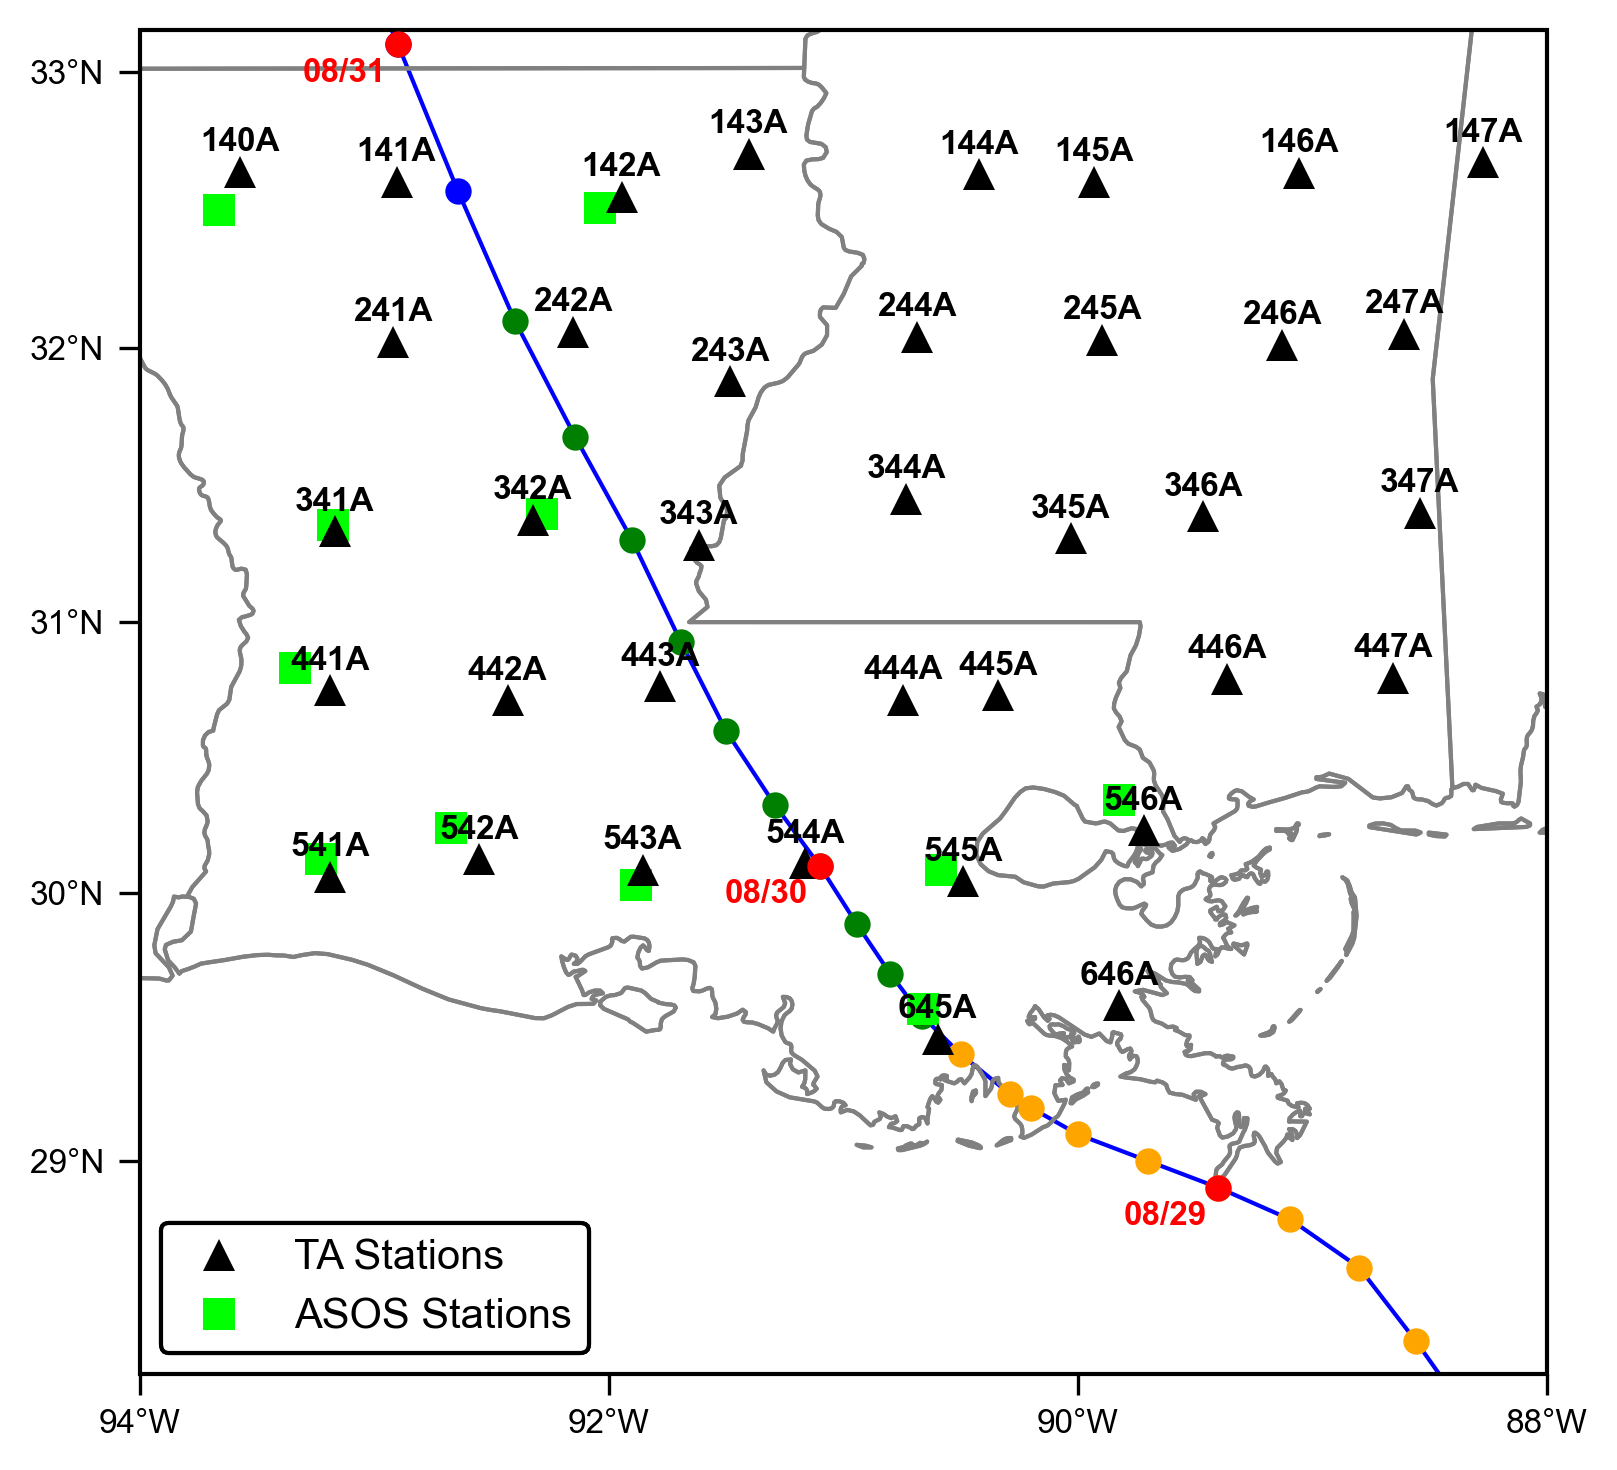

In [ ]:
# Hurricane information: 2012 Isaac
tc_info = tc_func.get_tc_info(year=2012, name='Isaac', agency='USA')
f_loc, t0 = tc_func.get_interp_func(tc_info)

# Plotting area
extent = [-94, -88, 28.2, 33.15]
stnm_list = sta_info[
    (sta_info['lon'] >= extent[0]) & (sta_info['lon'] <= extent[1]) &
    (sta_info['lat'] >= extent[2]) & (sta_info['lat'] <= extent[3])
]

# Map projection
proj = ccrs.Mercator()
proj_data = ccrs.PlateCarree()
fig = plt.figure(dpi=300)
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj_data)
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, edgecolor='gray')

# Plot specific station
for stnm_ in stnm_list['stnm'].values.tolist():
    one_info = sta_info[sta_info['stnm']==stnm_]
    obj_sta, = ax.plot(one_info['lon'].iloc[0], one_info['lat'].iloc[0],
            ms=np.sqrt(60), c='k', marker='^', mec='None', ls='None', 
            transform=proj_data, label='TA Stations', zorder=10)
    ax.text(one_info['lon'].iloc[0], one_info['lat'].iloc[0]+0.05, f'{stnm_}', color='k', 
            transform=proj_data, horizontalalignment='center', 
            verticalalignment='bottom', fontsize=8, fontweight='bold', zorder=11)

# Plot nearby ASOS stations
obj_asos, = ax.plot(match_info['asos_lon'], match_info['asos_lat'], ls='None',
                    ms=np.sqrt(60), c='lime', marker='s', mec='None',
                    transform=proj_data, label='ASOS Stations', zorder=8)

# Plot TC track
marker_size = np.sqrt(40)
obj_tc_track, = ax.plot(tc_info['lon'], tc_info['lat'], 'b-', 
                        transform=proj_data, label='Hurricane Track', zorder=1)
obj_dot_1, = ax.plot(tc_info['lon'][tc_info['scale'] == 1],
                        tc_info['lat'][tc_info['scale'] == 1],
                        ms=marker_size, c='orange', marker='o', mec='None', ls='None',
                        transform=proj_data, label='Category 1 Hurricane')
obj_dot_2, = ax.plot(tc_info['lon'][tc_info['scale'] == 0],
                        tc_info['lat'][tc_info['scale'] == 0],
                        ms=marker_size, c='green', marker='o', mec='None', ls='None',
                        transform=proj_data, label='Tropical Storm')
obj_dot_3, = ax.plot(tc_info['lon'][tc_info['scale'] == -1],
                        tc_info['lat'][tc_info['scale'] == -1],
                        ms=marker_size, c='blue', marker='o', mec='None', ls='None',
                        transform=proj_data, label='Tropical Depression')

# Plot date marker
t0 = tc_info['time'][0]
for tc_time in [UTCDateTime('20120826-00'), UTCDateTime('20120827-00'), 
                UTCDateTime('20120828-00'), UTCDateTime('20120829-00'), 
                UTCDateTime('20120830-00'), UTCDateTime('20120831-00'), 
                UTCDateTime('20120901-00')]:
    tc_lon = f_loc[0](tc_time-UTCDateTime(t0))
    tc_lat = f_loc[1](tc_time-UTCDateTime(t0))
    obj_date, = ax.plot(tc_lon, tc_lat, ms=marker_size, c='r', marker='o', 
                        mec='None', ls='None', transform=proj_data, 
                        zorder=10, label='Date Marker')

for tc_time in [UTCDateTime('20120829-00'), UTCDateTime('20120830-00'), UTCDateTime('20120831-00')]:
    tc_lon = f_loc[0](tc_time-UTCDateTime(t0))
    tc_lat = f_loc[1](tc_time-UTCDateTime(t0))
    obj_text = ax.text(tc_lon-0.05, tc_lat-0.05, r'%02d/%02d' 
                        %(tc_time.month, tc_time.day), color='red', 
                        transform=proj_data, horizontalalignment='right',
                        verticalalignment='top', fontsize=8, 
                        fontweight='bold', zorder=10)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linestyle='--')
gl.xlines = False
gl.ylines = False

xtick_loc = np.arange(-94, -86, 2)
ytick_loc = np.arange(29, 34, 1)
gl.xlocator = mticker.FixedLocator(xtick_loc)
gl.ylocator = mticker.FixedLocator(ytick_loc)
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
ax.set_xticks(xtick_loc, crs=proj_data)
ax.set_yticks(ytick_loc, crs=proj_data)
ax.tick_params(axis="both", direction='out', length=5)

ax.add_artist(ax.legend(handles=[obj_sta, obj_asos], 
              loc='lower left'))

# fig.savefig(os.path.join(sup_dir, 'TA_turb', f'stations.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Gust factor

In [23]:
### Calculate gust factor ###
from scipy.signal import hilbert

# Directory of infrasound data
turb_dir = os.path.join(data_dir, 'TA/mseeds')

# Time range
ts, te = UTCDateTime(2012,8,27,0), UTCDateTime(2012,9,1,0)

# Window for gust factor
gust_window = 60
mean_window = 10 * 60

out_dir = os.path.join(data_dir, 'TA/turbulence')
os.makedirs(out_dir, exist_ok=True)
for stnm in ['645A']:

    # Read infrasound data
    st = read(os.path.join(turb_dir, f'BDF_{stnm}.mseed'))
    st = st.trim(starttime=ts, endtime=te)
    t0 = st[0].stats.starttime

    # Filter & Envelope
    st.filter('bandpass', freqmin=frms_min, freqmax=frms_max)
    # env_st = np.abs(hilbert(st[0].data))
    # st[0].data = env_st

    # Loop over intervals
    t_hr_arr, gust_arr = [], []
    psqrt_max_arr, psqrt_mean_arr = [], []
    for st_hr in st.slide(window_length=mean_window, step=mean_window, nearest_sample=False):
        st_hr.merge(fill_value=np.nan)
        if np.isnan(st_hr[0].data).all():
            continue

        # Gust factor
        psqrt_max = np.nanmax(np.sqrt(np.abs(st_hr[0].data)))
        psqrt_mean = np.sqrt(np.nanstd(st_hr[0].data))
        gust_factor = psqrt_max / psqrt_mean

        # Store results
        rel_hr = (st_hr[0].stats.starttime - t0) / 3600
        t_hr_arr.append(rel_hr)
        gust_arr.append(gust_factor)
        psqrt_max_arr.append(psqrt_max)
        psqrt_mean_arr.append(psqrt_mean)
    

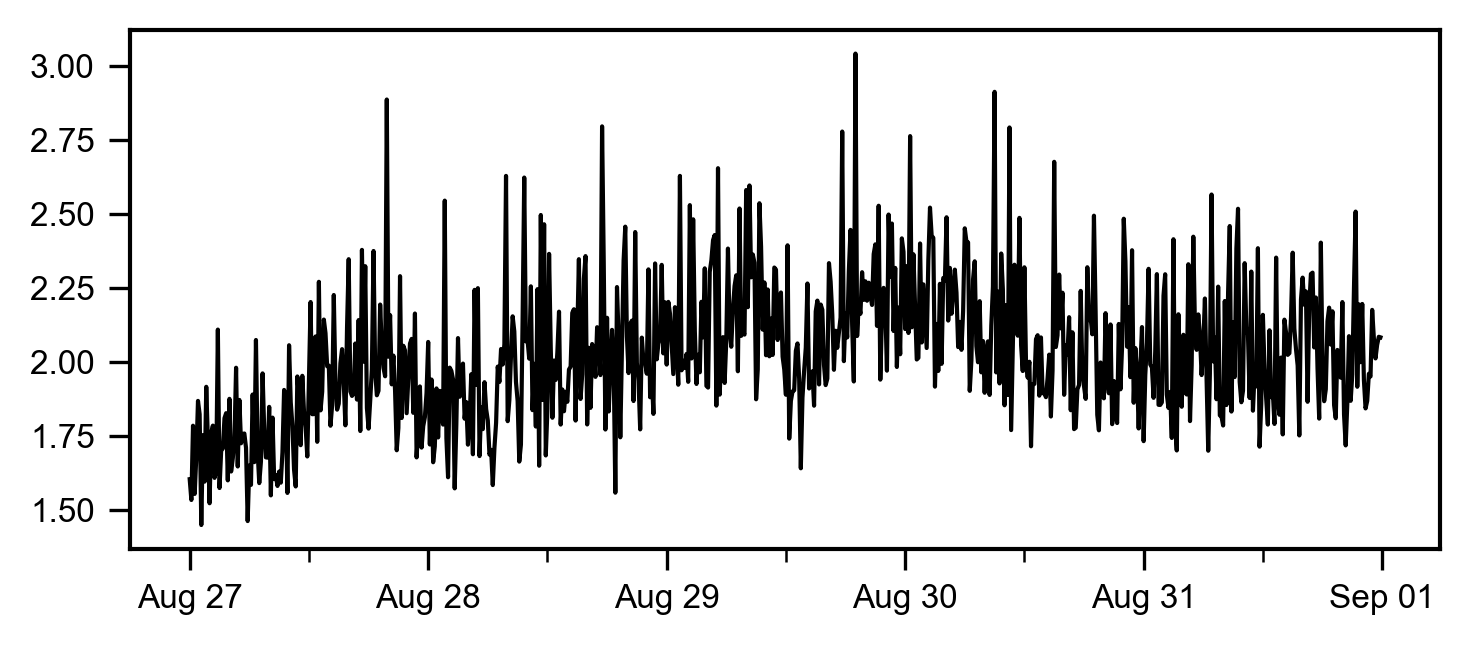

In [24]:
t_prs = np.array([t0 + pd.Timedelta(hours=h) for h in t_hr_arr])
t_prs_mpl = np.array([obj.matplotlib_date for obj in t_prs])

fig, ax = plt.subplots(figsize=(5, 2.25))
ax.plot(t_prs_mpl, gust_arr, 'k-')
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

In [ ]:
    # Running mean over gust window

    # Loop over intervals
    t_hr_arr, rms_arr = [], []
    psd_arr, psd_sm_arr = [], []
    for st_hr in st.slide(window_length=window, step=window, nearest_sample=False):
        st_hr.merge(fill_value=np.nan)
        if np.isnan(st_hr[0].data).all():
            continue

        # RMS amplitude
        filt_tr = st_hr[0].copy().filter('bandpass', freqmin=frms_min, freqmax=frms_max)
        rms_p = np.nanstd(filt_tr.data)

        # PSD
        filt_tr = st_hr[0].copy().filter('bandpass', freqmin=fmin, freqmax=fmax)
        psd_p, freqs = fspec.my_welch(filt_tr.data, dt, nperseg=nperseg, noverlap=noverlap, ave_method='mean')
        freqs_ = freqs.copy()
        freqs = 10 ** np.linspace(np.log10(freqs[0]), np.log10(freqs[-1]), 200)

        # Smoothed spectra
        psd_p_sm, _ = fspec.smooth_spectrum(freqs_, psd_p, smooth_npts, interp=True, f_out=freqs, 
                                            smooth_mode=smooth_mode, polyorder=smooth_poly)

        # Store results
        rel_hr = (st_hr[0].stats.starttime - t0) / 3600
        t_hr_arr.append(rel_hr)
        rms_arr.append(rms_p)
        psd_arr.append(psd_p)
        psd_sm_arr.append(psd_p_sm)
